###Mount Google Drive

In [8]:
!pip install nibabel scikit-learn
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###Import necessary libraries

In [ ]:
import os
import numpy as np
import nibabel as nib
import cv2

# ================= CONFIGURATION =================
AFRICA_BASE = '/content/drive/My Drive/Computer Vision Project/datasets/BraTS-Africa'
SUBFOLDERS = ['95_Glioma', '51_OtherNeoplasms']
OUTPUT_ROOT = '/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma'

SLICES_PER_PATIENT = 5
IMG_SIZE = (224, 224)
# =================================================

def normalize_slice(slice_data):
    p99 = np.percentile(slice_data, 99)
    slice_data = np.clip(slice_data, 0, p99)
    img_min, img_max = slice_data.min(), slice_data.max()
    if img_max - img_min == 0:
        return slice_data.astype(np.uint8)
    return (((slice_data - img_min) / (img_max - img_min)) * 255).astype(np.uint8)

def process_all_african_scans():
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    total_images, total_patients = 0, 0

    for subf in SUBFOLDERS:
        folder_path = os.path.join(AFRICA_BASE, subf)
        if not os.path.exists(folder_path):
            print(f"⚠️ Warning: Folder not found ({folder_path}). Skipping.")
            continue

        patient_dirs = sorted([d for d in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, d))])
        print(f"\n📂 Processing {len(patient_dirs)} patients from '{subf}'...")

        for pat_id in patient_dirs:
            pat_path = os.path.join(folder_path, pat_id)

            possible_t2_files = [f"{pat_id}-t2w.nii.gz", f"{pat_id}-t2.nii.gz", f"{pat_id}-t2f.nii.gz", f"{pat_id}-fla.nii.gz"]
            t2_path = None

            for fname in possible_t2_files:
                if os.path.exists(os.path.join(pat_path, fname)):
                    t2_path = os.path.join(pat_path, fname)
                    break

            seg_path = os.path.join(pat_path, f"{pat_id}-seg.nii.gz")

            if t2_path is None or not os.path.exists(seg_path):
                print(f"  ⚠️ Skipping {pat_id}: T2 or Seg file missing.")
                continue

            try:
                t2_vol = nib.load(t2_path).get_fdata()
                seg_vol = nib.load(seg_path).get_fdata()
            except Exception as e:
                print(f"  ❌ Error loading {pat_id}: {e}")
                continue

            slice_scores = [(z, np.sum(seg_vol[:, :, z] > 0)) for z in range(seg_vol.shape[2]) if np.sum(seg_vol[:, :, z] > 0) > 0]
            top_slices = sorted(slice_scores, key=lambda x: x[1], reverse=True)[:SLICES_PER_PATIENT]

            for (z_index, area) in top_slices:
                img_slice = np.rot90(t2_vol[:, :, z_index], k=1)
                img_resized = cv2.resize(normalize_slice(img_slice), IMG_SIZE, interpolation=cv2.INTER_CUBIC)
                cv2.imwrite(os.path.join(OUTPUT_ROOT, f"{pat_id}_slice{z_index}_t2.png"), img_resized)
                total_images += 1

            total_patients += 1

    print(f"\n🎉 DONE! Extracted {total_images} total T2 images across {total_patients} patients to:\n{OUTPUT_ROOT}")

process_all_african_scans()


📂 Processing 95 patients from '95_Glioma'...

📂 Processing 51 patients from '51_OtherNeoplasms'...

🎉 DONE! Extracted 730 total T2 images across 146 patients to:
/content/drive/My Drive/Computer Vision Project/datasets/braTS_africa_test/glioma


In [13]:
import os, shutil, glob

# 1. Force-delete the old local cache
if os.path.exists('/tmp/datasets'):
    shutil.rmtree('/tmp/datasets')
    print("🧹 Cleared stale local cache.")

# 2. Re-copy fresh data from Google Drive
path_mydrive = '/content/drive/MyDrive/Computer Vision Project/datasets'
path_my_drive = '/content/drive/My Drive/Computer Vision Project/datasets'
DRIVE_BASE = path_mydrive if os.path.exists(path_mydrive) else path_my_drive

print("⚡ Copying fresh dataset from Drive to local SSD...")
shutil.copytree(DRIVE_BASE, '/tmp/datasets')

# 3. Verify healthy scans exist
healthy_path = '/tmp/datasets/nigerian_healthy/axial'
files = glob.glob(os.path.join(healthy_path, '**', '*.png'), recursive=True) + \
        glob.glob(os.path.join(healthy_path, '**', '*.jpg'), recursive=True)

print(f"✅ Found {len(files)} healthy image files in local SSD.")

🧹 Cleared stale local cache.
⚡ Copying fresh dataset from Drive to local SSD...
✅ Found 25 healthy image files in local SSD.


In [14]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Config
SEEDS = [12, 23, 42, 2026]
SPLIT_RATIO = 0.40  # 40% African tumor held out for external validation
NUM_EPOCHS = 25
BATCH_SIZE = 32
NUM_WORKERS = 2
USE_AMP = device.type == 'cuda'

# Environment Setup
path_mydrive = '/content/drive/MyDrive/Computer Vision Project/datasets'
path_my_drive = '/content/drive/My Drive/Computer Vision Project/datasets'
DRIVE_BASE = path_mydrive if os.path.exists(path_mydrive) else path_my_drive
LOCAL_BASE = '/tmp/datasets'

if not os.path.exists(LOCAL_BASE):
    print("⚡ Copying dataset from Drive to fast Colab SSD...")
    shutil.copytree(DRIVE_BASE, LOCAL_BASE)

BASE_DIR = LOCAL_BASE
AFRICAN_TUMOR_DIR = os.path.join(BASE_DIR, 'braTS_africa_test', 'glioma')
WESTERN_TUMOR_DIR = os.path.join(BASE_DIR, 'tumor')
WESTERN_HEALTHY_DIR = os.path.join(BASE_DIR, 'axial')
AFRICAN_HEALTHY_DIR = os.path.join(BASE_DIR, 'nigerian_healthy', 'axial') # Loads axial healthy controls

SAVE_WEIGHTS_DIR = os.path.join(os.path.dirname(DRIVE_BASE), 'checkpoints')
os.makedirs(SAVE_WEIGHTS_DIR, exist_ok=True)

class MRIDataset(Dataset):
    def __init__(self, filepaths, labels, transform=None):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_patient_id(filename):
    base = os.path.basename(filename)
    return base.split('_slice')[0] if '_slice' in base else base.split('.')[0]

def scan_dir(directory, label):
    filepaths, labels, groups = [], [], []
    if os.path.exists(directory):
        for ext in ('*.png', '*.jpg', '*.jpeg'):
            for f in glob.glob(os.path.join(directory, '**', ext), recursive=True):
                filepaths.append(f)
                labels.append(label)
                groups.append(extract_patient_id(f))
    return pd.DataFrame({'filepath': filepaths, 'label': labels, 'patient_id': groups})

class FocalLossWithLogits(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        return (self.alpha * ((1 - pt) ** self.gamma) * bce).mean()

class DINOv2Classifier(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.backbone.blocks[-2:].parameters():
            param.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(-1)

# Scan Datasets
df_afr_tumor = scan_dir(AFRICAN_TUMOR_DIR, label=1)
df_west_tumor = scan_dir(WESTERN_TUMOR_DIR, label=1)
df_west_healthy = scan_dir(WESTERN_HEALTHY_DIR, label=0)
df_afr_healthy = scan_dir(AFRICAN_HEALTHY_DIR, label=0)  # 100% held out for evaluation

for seed in SEEDS:
    print(f"\n--- Training Seed {seed} ---")

    # Patient-level split on African Tumors (60% Train / 40% External Val)
    gss = GroupShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=seed)
    train_idx, _ = next(gss.split(df_afr_tumor, groups=df_afr_tumor['patient_id']))
    afr_tumor_train = df_afr_tumor.iloc[train_idx]

    # Combine training data (60% African Tumor + Western Tumors + Western Healthy)
    train_df = pd.concat([afr_tumor_train, df_west_tumor, df_west_healthy]).sample(frac=1, random_state=seed).reset_index(drop=True)
    train_loader = DataLoader(MRIDataset(train_df['filepath'].values, train_df['label'].values, train_transforms), BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    model = DINOv2Classifier(backbone).to(device)
    criterion = FocalLossWithLogits()
    optimizer = optim.AdamW([
        {'params': model.backbone.blocks[-2:].parameters(), 'lr': 1e-5},
        {'params': model.classifier.parameters(), 'lr': 1e-3}
    ], weight_decay=1e-2)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    for epoch in range(NUM_EPOCHS):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=USE_AMP):
                loss = criterion(model(images), labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

    torch.save(model.state_dict(), os.path.join(SAVE_WEIGHTS_DIR, f"dinov2_seed_{seed}.pth"))
    print(f"✅ Checkpoint saved for Seed {seed}")


--- Training Seed 12 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Checkpoint saved for Seed 12

--- Training Seed 23 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Checkpoint saved for Seed 23

--- Training Seed 42 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Checkpoint saved for Seed 42

--- Training Seed 2026 ---


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


✅ Checkpoint saved for Seed 2026


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main



EXTERNAL VALIDATION METRICS (AFRICAN COHORT)
 Seed  Sensitivity (%)  Specificity (%)    AUC
   12           100.00             92.0 1.0000
   23           100.00             64.0 1.0000
   42            99.66             92.0 0.9989
 2026            98.98             96.0 0.9992



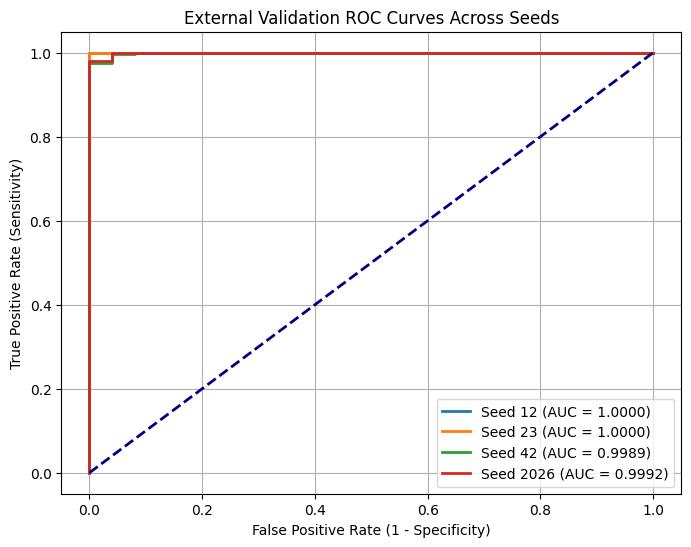

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

plt.figure(figsize=(8, 6))
summary_results = []

for seed in SEEDS:
    # Patient-level split for African Tumors to reconstruct holdout set
    gss = GroupShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=seed)
    _, val_idx = next(gss.split(df_afr_tumor, groups=df_afr_tumor['patient_id']))
    afr_tumor_val = df_afr_tumor.iloc[val_idx]

    # Strictly African External Validation Set (40% African Tumor + 100% African Healthy)
    ext_val_df = pd.concat([afr_tumor_val, df_afr_healthy]).reset_index(drop=True)
    ext_val_loader = DataLoader(MRIDataset(ext_val_df['filepath'].values, ext_val_df['label'].values, val_transforms), BATCH_SIZE, shuffle=False)

    backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
    model = DINOv2Classifier(backbone).to(device)
    checkpoint_path = os.path.join(SAVE_WEIGHTS_DIR, f"dinov2_seed_{seed}.pth")
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    y_true, y_probs = [], []
    with torch.no_grad():
        for images, labels in ext_val_loader:
            outputs = model(images.to(device))
            probs = torch.sigmoid(outputs)
            y_probs.extend(probs.cpu().numpy())
            y_true.extend(labels.numpy())

    # Compute binary metrics
    y_pred = (np.array(y_probs) >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    summary_results.append({
        'Seed': seed,
        'Sensitivity (%)': round(sens * 100, 2),
        'Specificity (%)': round(spec * 100, 2),
        'AUC': round(roc_auc, 4)
    })

    plt.plot(fpr, tpr, lw=2, label=f'Seed {seed} (AUC = {roc_auc:.4f})')

# Display Metrics Table
print("\n" + "="*50 + "\nEXTERNAL VALIDATION METRICS (AFRICAN COHORT)\n" + "="*50)
print(pd.DataFrame(summary_results).to_string(index=False))
print("="*50 + "\n")

# Format & Save ROC Plot
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('External Validation ROC Curves Across Seeds')
plt.legend(loc="lower right")
plt.grid(True)

plot_save_path = os.path.join(SAVE_WEIGHTS_DIR, 'external_val_roc_curves.png')
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
plt.show()